# IMC Prosperity 4 - Tutorial Round EDA 

**Author:** Tristan Trieu  
**Date:** April 2026  
**Objective:** Explore the tutorial round data to understand asset behaviour and inform trading strategy development

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

Step 1: Load and Inspect the Data  

In [ ]:
df = pd.read_csv("../tutorial-data/prices_round_0_day_-1.csv", sep = ';')
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0


In [ ]:
print(df.isnull().sum())
print(df.shape)
print(df.columns)

day                    0
timestamp              0
product                0
bid_price_1            0
bid_volume_1           0
bid_price_2            0
bid_volume_2           0
bid_price_3        19475
bid_volume_3       19475
ask_price_1            0
ask_volume_1           0
ask_price_2            0
ask_volume_2           0
ask_price_3        19482
ask_volume_3       19482
mid_price              0
profit_and_loss        0
dtype: int64
(20000, 17)
Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')


The data contains 20,000 rows and 17 attributes: 
- day, timestamp: when each transaction takes place 
- product: TOMATOES and EMERALDS
- bid_price_1/2/3, bid_volume_1/2/3: 3 levels of buy orders (price and volume at each level)
- ask_price_1/2/3, ask_volume_1/2/3: 3 levels of ask orders (price and volume at each level)
- mid_price: average of ask_price_1 and bid_price_1 (lowest price seller could accept and highest price buyer is willing to deal) ==> a variable that reflects general market price (useful)
- profit_and_loss (PnL): profit and loss generated - not available yet (tutorial round)  
==> The reason why there are many N/A records from bid_price_3, bid_volume_3, ask_price_3 and ask_volume_3 is because the order book does not have a depth of 3 levels 

Step 2: Separate the data into individual assets for independent analysis

In [ ]:
emeralds = df[df['product'] == 'EMERALDS'].copy().reset_index(drop = True)
tomatoes = df[df['product'] == 'TOMATOES'].copy().reset_index(drop = True)

print(f"Emeralds: {emeralds.shape[0]} rows")
print(f"Tomatoes: {tomatoes.shape[0]} rows")

Emeralds: 10000 rows
Tomatoes: 10000 rows


Step 3: Plot Mid-price over Time 

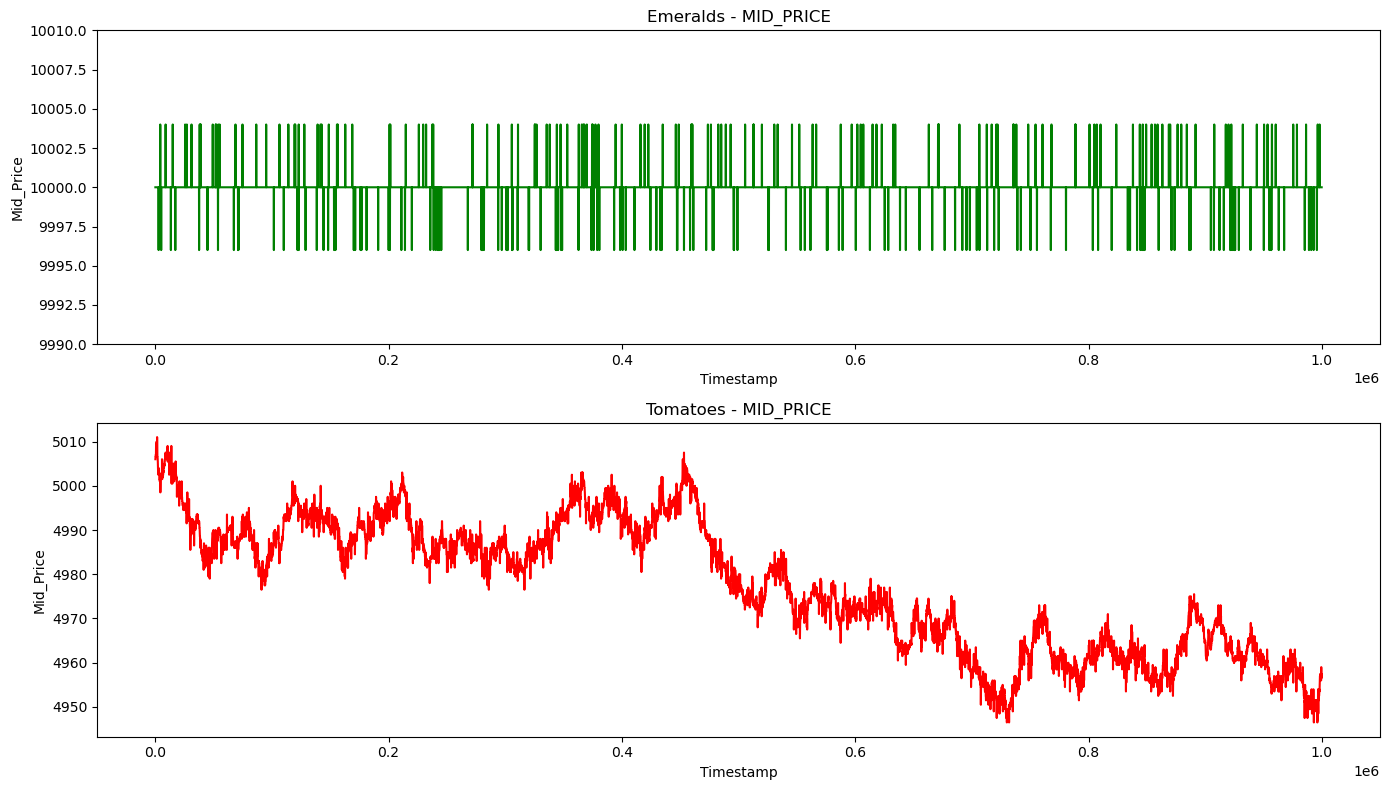

In [ ]:
fig, axes = plt.subplots(2,1, figsize = (14,8))

# Emeralds
axes[0].plot(emeralds['timestamp'], emeralds['mid_price'], color = "green")
axes[0].set_title("Emeralds - MID_PRICE")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Mid_Price")
axes[0].set_ylim(9990, 10010)

# Tomatoes
axes[1].plot(tomatoes['timestamp'], tomatoes['mid_price'], color = "red")
axes[1].set_title("Tomatoes - MID_PRICE")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Mid_Price")

plt.tight_layout()
plt.show()

**Observations:**
- **Emeralds:**: Mid_price barely fluctuates, staying within 4 units from 10,000 in mid_price ==> This is a stationary asset, suitable for market making with a fixed fair value of 10,000.
- **Tomatoes:**: Mid_price shows a downward drift, moving from -5,010 to -4,950 over the day. This is a non-stationary (drifting) asset - a static fair value will not work. We need another dynamic metric like an EMA (Exponential Moving Average) to track the moving center.

## Step 4: Spread Analytics 

In [ ]:
emeralds['spread'] = emeralds['ask_price_1'] - emeralds['bid_price_1']
tomatoes['spread'] = tomatoes['ask_price_1'] - tomatoes['bid_price_1']

print("EMERALDS' SPREAD")
print(emeralds['spread'].describe())
print("\nTOMATOES' SPREAD")
print(tomatoes['spread'].describe())

EMERALDS' SPREAD
count    10000.000000
mean        15.743200
std          1.410196
min          8.000000
25%         16.000000
50%         16.000000
75%         16.000000
max         16.000000
Name: spread, dtype: float64

TOMATOES' SPREAD
count    10000.000000
mean        12.975300
std          1.753453
min          5.000000
25%         13.000000
50%         13.000000
75%         14.000000
max         14.000000
Name: spread, dtype: float64


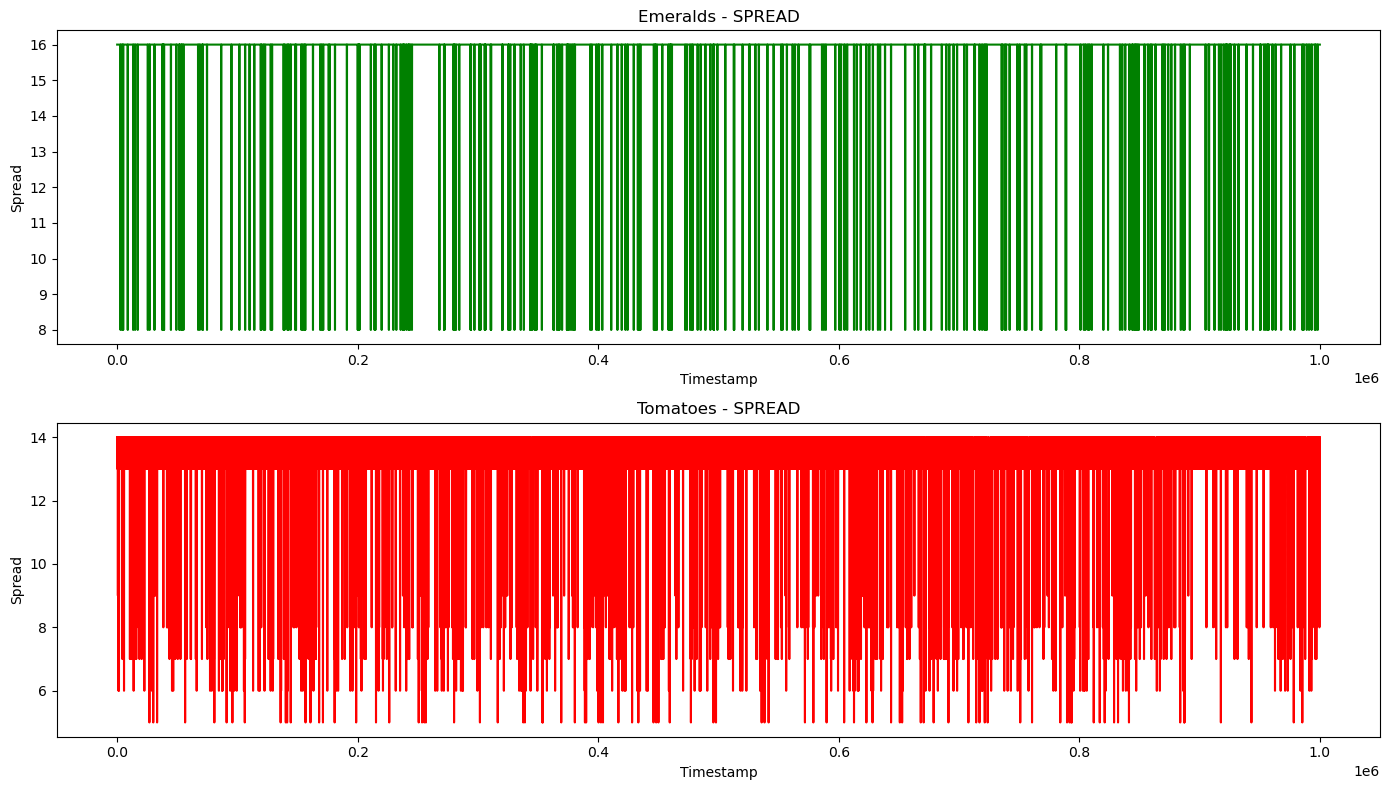

In [ ]:
fig, axes = plt.subplots(2,1, figsize = (14,8))
axes[0].plot(emeralds['timestamp'], emeralds['spread'], color = "green")
axes[0].set_title("Emeralds - SPREAD")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Spread")

# Tomatoes
axes[1].plot(tomatoes['timestamp'], tomatoes['spread'], color = "red")
axes[1].set_title("Tomatoes - SPREAD")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Spread")

plt.tight_layout()
plt.show()

**Observations**  
**Emeralds:** The spread consistently stays on 16, with occasional dips down to 8 (possibly a bot that places order closer to the fair value) ==> ideal for market-making.  
**Tomatoes:** The spread ranges from 5 to 14, spending most of it time around 13-14 but frequently dipping to 6-8. The book is more active and the market is more competitive here.

# Step 5: Returns and autocorrelation 

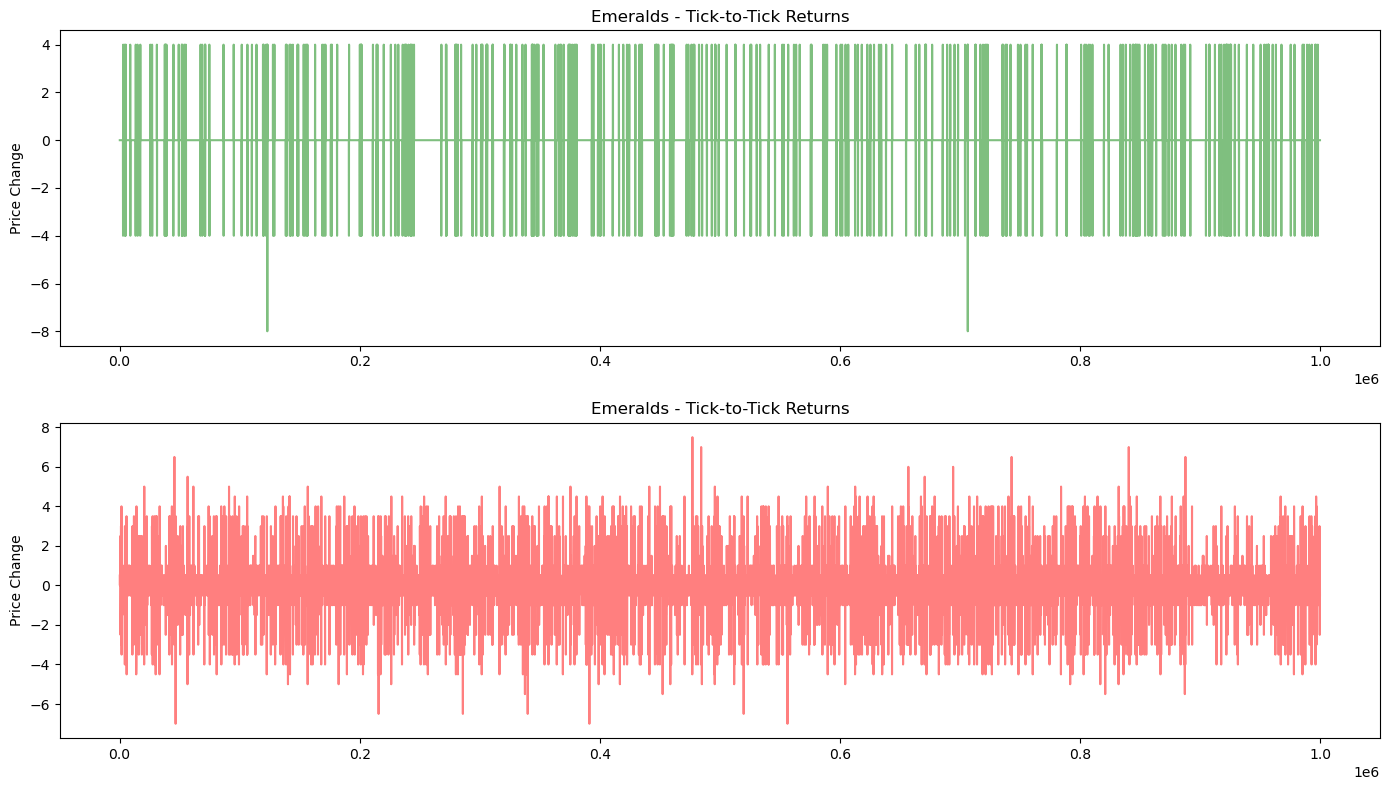

In [ ]:
emeralds['returns'] = emeralds['mid_price'].diff() 
tomatoes['returns'] = tomatoes['mid_price'].diff() 

fig, axes = plt.subplots(2,1, figsize = (14,8))
axes[0].plot(emeralds['timestamp'], emeralds['returns'], color = "green", alpha = 0.5)
axes[0].set_title("Emeralds - Tick-to-Tick Returns")
axes[0].set_ylabel("Price Change")

# Tomatoes
axes[1].plot(tomatoes['timestamp'], tomatoes['returns'], color = "red", alpha = 0.5)
axes[1].set_title("Emeralds - Tick-to-Tick Returns")
axes[1].set_ylabel("Price Change")

plt.tight_layout()
plt.show()

In [ ]:
print("EMERALDS lag-1 autocorrelation:", emeralds["returns"].autocorr(lag = 1))
print("TOMATOES lag-1 autocorrelation:", tomatoes["returns"].autocorr(lag = 1))

EMERALDS lag-1 autocorrelation: -0.4903846153846153
TOMATOES lag-1 autocorrelation: -0.41247964139638327


Negative autocorrelation indicates that both EMERALDS and TOMATOES show mean reversion at a one-tick level (from t-1 to t). Specifically, when price goes up at one tick, it has a strong tendency to go down the next tick, averaging around the fair value for EMERALDS. For TOMATOES, the story might be slightly different, as we might need dynamic fair value to handle the drift. 

# Step 6: Order book Depth

In [ ]:
print("EMERALDS - Bid Volumes: ")
print(emeralds[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].describe())
print("EMERALDS - Ask Volumes: ")
print(emeralds[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].describe())

EMERALDS - Bid Volumes: 
       bid_volume_1  bid_volume_2  bid_volume_3
count  10000.000000  10000.000000    158.000000
mean      12.457000     24.781500     24.930380
std        1.814519      3.515849      3.180588
min        5.000000     10.000000     20.000000
25%       11.000000     22.000000     22.000000
50%       13.000000     25.000000     25.000000
75%       14.000000     28.000000     27.750000
max       15.000000     30.000000     30.000000
EMERALDS - Ask Volumes: 
       ask_volume_1  ask_volume_2  ask_volume_3
count  10000.000000  10000.000000    163.000000
mean      12.462700     24.767300     25.110429
std        1.808075      3.543925      3.138778
min        5.000000     10.000000     20.000000
25%       11.000000     22.000000     22.500000
50%       13.000000     25.000000     25.000000
75%       14.000000     28.000000     28.000000
max       15.000000     30.000000     30.000000


In [ ]:
print("TOMATOES - Bid Volumes: ")
print(tomatoes[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].describe())
print("TOMATOES - Ask Volumes: ")
print(tomatoes[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].describe())

TOMATOES - Bid Volumes: 
       bid_volume_1  bid_volume_2  bid_volume_3
count  10000.000000   10000.00000    367.000000
mean       7.453900      19.57500     20.188011
std        1.796886       3.88596      3.295977
min        2.000000       5.00000      5.000000
25%        6.000000      17.00000     18.000000
50%        7.000000      20.00000     21.000000
75%        9.000000      23.00000     23.000000
max       12.000000      25.00000     25.000000
TOMATOES - Ask Volumes: 
       ask_volume_1  ask_volume_2  ask_volume_3
count  10000.000000  10000.000000    355.000000
mean       7.464800     19.592100     20.078873
std        1.799246      3.885644      3.192413
min        1.000000      5.000000     15.000000
25%        6.000000     17.000000     17.000000
50%        7.000000     20.000000     20.000000
75%        9.000000     23.000000     23.000000
max       12.000000     25.000000     25.000000


**Observations:**
- Both assets have a 2-level order book.
- **Emeralds:** Around 12 units at level 1, 25 units at level 2. Decent liquidity - We might trade 12 units per side at best price.
- **Tomatoes:** Around 7 units at level 1, 20 units at level 2. Thinner at the top, less available for trades.
Level 2 holds the bulk of liquidity. Mid-price from level 2 orders might be more consistent than mid-price from level 1 (as the liquidity is higher here, while for level 1 e.g Tomatoes has only 7 units, one small change might deeply affect the price).


# Step 8: Comparison with Day 2 

In [ ]:
df2 = pd.read_csv("../tutorial-data/prices_round_0_day_-2.csv", sep=";")
em2 = df2[df2['product'] == 'EMERALDS'].copy()
tm2 = df2[df2['product'] == 'TOMATOES'].copy()
em2['returns'] = em2['mid_price'].diff()
tm2['returns'] = tm2['mid_price'].diff()

print("=== DAY -2 vs DAY -1 ===")
print(f"Emeralds mid mean: Day-2={em2['mid_price'].mean():.1f}, Day-1={emeralds['mid_price'].mean():.1f}")
print(f"Emeralds spread mean: Day-2={(em2['ask_price_1']-em2['bid_price_1']).mean():.1f}, Day-1={emeralds['spread'].mean():.1f}")
print(f"Emeralds autocorr: Day-2={em2['returns'].autocorr(lag=1):.3f}, Day-1={emeralds['returns'].autocorr(lag=1):.3f}")
print()
print(f"Tomatoes mid mean: Day-2={tm2['mid_price'].mean():.1f}, Day-1={tomatoes['mid_price'].mean():.1f}")
print(f"Tomatoes spread mean: Day-2={(tm2['ask_price_1']-tm2['bid_price_1']).mean():.1f}, Day-1={tomatoes['spread'].mean():.1f}")
print(f"Tomatoes autocorr: Day-2={tm2['returns'].autocorr(lag=1):.3f}, Day-1={tomatoes['returns'].autocorr(lag=1):.3f}")

=== DAY -2 vs DAY -1 ===
Emeralds mid mean: Day-2=10000.0, Day-1=10000.0
Emeralds spread mean: Day-2=15.7, Day-1=15.7
Emeralds autocorr: Day-2=-0.485, Day-1=-0.490

Tomatoes mid mean: Day-2=5007.9, Day-1=4977.6
Tomatoes spread mean: Day-2=13.1, Day-1=13.0
Tomatoes autocorr: Day-2=-0.428, Day-1=-0.412


Numbers seem very identical here between Day -1 and Day -2. The only noticable difference lies in Tomatoes mid mean. This confirms our theory about the drift in average price of Tomatoes, shifted down by about 30 between days. This also means that our observations from day -1 are robust and consistent. 

## Summary and Trading Implications

### EMERALDS (Stationary Asset)
- **Fair value:** 10,000 (stable across both days)
- **Spread:** ~16, very stable
- **Autocorrelation:** -0.49 (strong mean reversion)
- **Book depth:** ~12 units at level 1, ~25 at level 2
- **Strategy:** Static market making. Buy below 10,000, sell above 10,000. Use fixed fair value. Skew quotes based on inventory.

### TOMATOES (Drifting Asset)
- **Fair value:** Not fixed — drifts over time (5,007 → 4,977 between days)
- **Spread:** ~13, moderately stable
- **Autocorrelation:** -0.41 (mean reversion at tick level, but overall price drifts)
- **Book depth:** ~7 units at level 1, ~20 at level 2
- **Strategy:** Dynamic market making. Use a short EMA to track the moving fair value. Market-make around the EMA, not a fixed number. Skew quotes based on inventory.

### Next Steps
1. Build a StaticTrader for Emeralds with fair value = 10,000
2. Build a DynamicTrader for Tomatoes with EMA-based fair value
3. Implement take → clear → make execution schema for both
4. Backtest using jmerle backtester and iterate on parameters